# Day 7: Qubits and Dirac notation

**Mon, Oct 12 · Intro · about 30 minutes**

This is a light first look. Dirac notation is just a compact way of writing the vectors from Day 2, and the course will cover it properly in Module 2.

**By the end of this notebook you can:**
- Read |ψ⟩ as a column vector and ⟨ψ| as a conjugated row
- Write superpositions like |+⟩ and |−⟩
- Compute ⟨φ|ψ⟩ and say what it means

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label

## 1. Kets are column vectors
| Dirac | Vector | Meaning |
|---|---|---|
| \|0⟩ | (1, 0) | the qubit's "0" basis state |
| \|1⟩ | (0, 1) | the qubit's "1" basis state |
| α\|0⟩ + β\|1⟩ | (α, β) | a **superposition**; needs \|α\|² + \|β\|² = 1 |
| ⟨ψ\| | conjugate row of \|ψ⟩ | a "bra" |
| ⟨φ\|ψ⟩ | np.vdot(φ, ψ) | inner product ("bra-ket") |

In [2]:
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
plus = (ket0 + ket1) / np.sqrt(2)
minus = (ket0 - ket1) / np.sqrt(2)

print("|0> =", ket0, "  |1> =", ket1)
print("|+> =", plus)
print("|-> =", minus)

|0> = [1.+0.j 0.+0.j]   |1> = [0.+0.j 1.+0.j]
|+> = [0.7071+0.j 0.7071+0.j]
|-> = [ 0.7071+0.j -0.7071+0.j]


## 2. Picture the four standard states
With real amplitudes you can draw a state as an arrow in the (|0⟩, |1⟩) plane.
|+⟩ and |−⟩ sit at ±45°. They form a second basis that's just as valid as {|0⟩, |1⟩}.

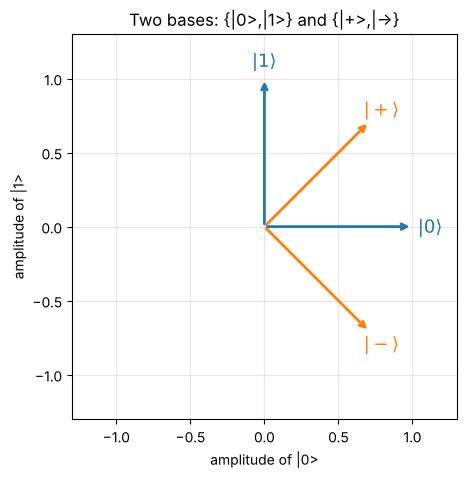

In [3]:
fig, ax = plt.subplots()
for vec, lab, c in [(ket0, "|0>", "C0"), (ket1, "|1>", "C0"), (plus, "|+>", "C1"), (minus, "|->", "C1")]:
    ax.annotate("", xy=vec.real, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(vec.real[0] * 1.12, vec.real[1] * 1.12, tex(lab), color=c, ha="center", va="center", fontsize=13)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal")
ax.set_xlabel("amplitude of |0>"); ax.set_ylabel("amplitude of |1>")
ax.set_title("Two bases: {|0>,|1>} and {|+>,|->}"); plt.show()

## 3. Bra-kets
⟨φ|ψ⟩ measures overlap. ⟨0|1⟩ = 0 and ⟨+|−⟩ = 0, so each basis is **orthonormal**.
|⟨φ|ψ⟩|² is the probability of finding ψ in state φ when you measure in a basis containing φ.

In [4]:
def braket(phi, psi): return np.vdot(phi, psi)
print("<0|1> =", braket(ket0, ket1), "  <+|-> =", braket(plus, minus))
print("<0|+> =", braket(ket0, plus), " -> P(0) for |+> =", abs(braket(ket0, plus))**2)

<0|1> = 0j   <+|-> = (-2.2371143170757382e-17+0j)
<0|+> = (0.7071067811865475+0j)  -> P(0) for |+> = 0.4999999999999999


## Exercises
**E1.** Write |+⟩ = (|0⟩ + |1⟩)/√2 as a column vector and check it's normalised.

**E2.** Write |0⟩ in terms of |+⟩ and |−⟩.

In [5]:
# Your turn

<details>
<summary><b>Show worked solution</b></summary>

**E1.** |+⟩ = (1/√2, 1/√2). Norm² = 1/2 + 1/2 = 1. ✓

**E2.** |+⟩ + |−⟩ = (2/√2)|0⟩ = √2|0⟩, so **|0⟩ = (|+⟩ + |−⟩)/√2**.

</details>

In [6]:
assert np.isclose(np.linalg.norm(plus), 1)
assert np.allclose((plus + minus) / np.sqrt(2), ket0)
print("All Day 7 checks passed.")

All Day 7 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 8 (intro): Gates as matrices

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*